# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Load raw dataset
dataset_path = "../namadataset_raw/Bitcoin3.csv"
if not os.path.exists(dataset_path):
    dataset_path = "namadataset_raw/Bitcoin3.csv"

df = pd.read_csv(dataset_path)

print("Dataset Shape:", df.shape)
print("\nDataset Columns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())


Dataset Shape: (53150, 7)

Dataset Columns: ['Date', 'Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO']

First 5 rows:
                      Date    Close    Volume USDT        RSI  MACD_Hist  \
0  2017-09-21 09:00:00.000  3860.00   74434.891166  49.192454 -48.279697   
1  2017-09-21 10:00:00.000  3871.48   44687.318944  49.233202 -47.780476   
2  2017-09-21 11:00:00.000  3864.95   80546.171672  49.210685 -47.308061   
3  2017-09-21 12:00:00.000  3858.08   90331.531390  49.186948 -46.863233   
4  2017-09-21 13:00:00.000  3856.67  103405.818040  49.182064 -46.425379   

         ATR     KAMAO  
0  88.054720  2.495591  
1  87.996283  2.616710  
2  87.897128  2.532239  
3  87.720856  2.447245  
4  87.578086  2.424654  


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Missing Values:
Date           0
Close          0
Volume USDT    0
RSI            0
MACD_Hist      0
ATR            0
KAMAO          0
dtype: int64

Descriptive Statistics:
              Close   Volume USDT           RSI     MACD_Hist           ATR  \
count  53150.000000  5.315000e+04  53150.000000  53150.000000  53150.000000   
mean   20595.357333  6.919215e+07     50.403605      0.528272    221.733334   
std    15822.296994  1.059041e+08      3.210682    353.293188    208.401440   
min     3172.050000  0.000000e+00     35.178834  -1885.690630     17.436266   
25%     7976.915000  1.012558e+07     48.294197   -115.601600     72.702488   
50%    13878.095000  2.766119e+07     50.038483     10.154419    128.787616   
75%    29646.720000  8.944278e+07     52.406274    122.367509    325.616826   
max    68633.690000  3.005634e+09     64.657108   1430.405758   1004.531407   

              KAMAO  
count  53150.000000  
mean       0.229762  
std        5.168655  
min      -31.767152  
25%  

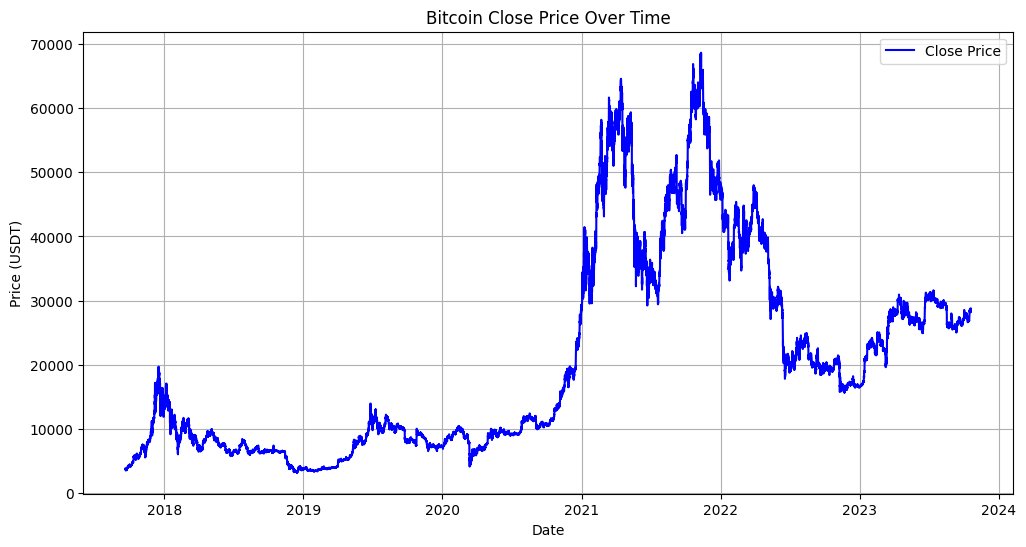

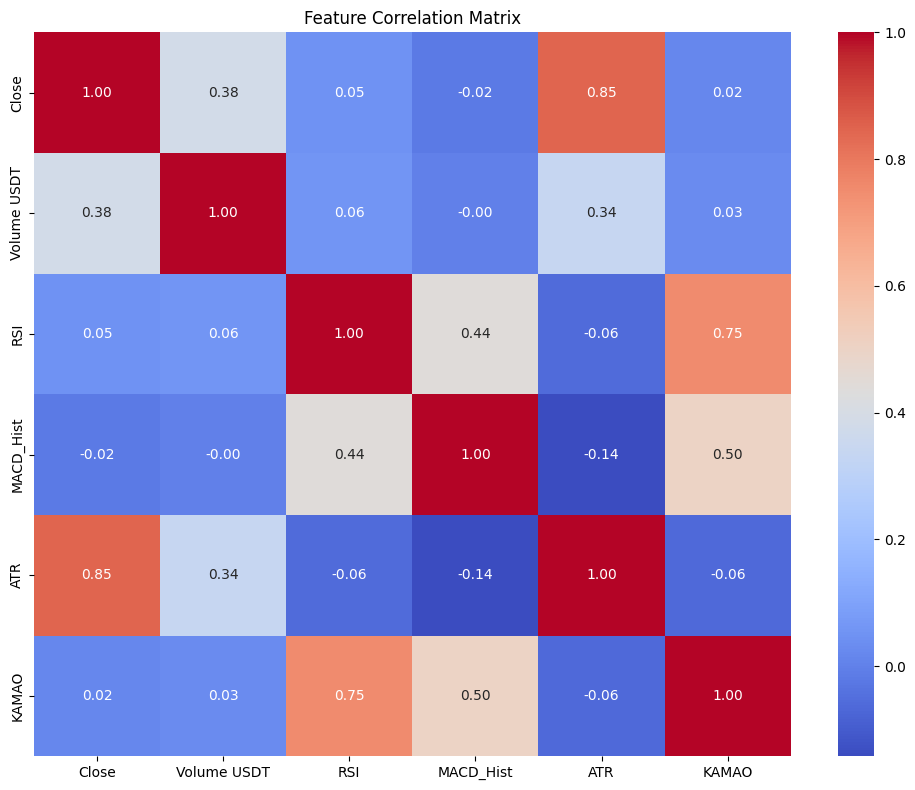

In [3]:
# 1. Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# 2. Descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())

# 3. Plot closing price trend
plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(df['Date'], format='mixed'), df['Close'], label='Close Price', color='blue')
plt.title('Bitcoin Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USDT)')
plt.legend()
plt.grid(True)
plt.savefig('bitcoin_close_trend.png')
plt.show()

# 4. Plot correlation heatmap
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png')
plt.show()


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# Preprocessing pipeline
# 1. Parse Date and sort
df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df = df.sort_values('Date').reset_index(drop=True)

# 2. Handle duplicates
dup_count = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Removed {dup_count} duplicate rows.")

# 3. Handle missing values (forward fill then backward fill for time series)
df = df.ffill().bfill()

# 4. Feature Engineering: Predict next hour's close price
df['Target'] = df['Close'].shift(-1)
df = df.dropna() # drop last row which has NaN target

# 5. Define features (X) and target (y)
X = df.drop(columns=['Date', 'Target'])
y = df['Target']

# 6. Train-test split (split chronologically for time series: 80% train, 20% test)
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# 7. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 8. Save preprocessed dataset to directory
output_dir = "namadataset_preprocessing"
os.makedirs(output_dir, exist_ok=True)

pd.DataFrame(X_train_scaled, columns=X.columns).to_csv(f"{output_dir}/X_train_scaled.csv", index=False)
pd.DataFrame(X_test_scaled, columns=X.columns).to_csv(f"{output_dir}/X_test_scaled.csv", index=False)
y_train.to_csv(f"{output_dir}/y_train.csv", index=False)
y_test.to_csv(f"{output_dir}/y_test.csv", index=False)

print(f"Successfully saved processed dataset files to {output_dir}/")


Removed 0 duplicate rows.
Train size: 42519, Test size: 10630
Successfully saved processed dataset files to namadataset_preprocessing/
